In [ ]:
import pandas as pd #used to load and handle dataset
import numpy as np #numerical operations
import time  #to measure training time of each search method
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  #splits dataset into training and testing
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  #tries all parameter combinations
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV  #efficient search

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#load dataset
data=pd.read_csv("WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
#convert into binary
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 5 else 0)
X = data.drop("quality", axis=1)
y = data["quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [8]:
# Parameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

results = {}
times = {}

model = RandomForestClassifier(random_state=42)


In [9]:
# Grid Search
start = time.time()
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)
end = time.time()

y_pred = grid.predict(X_test)

results["Grid"] = accuracy_score(y_test, y_pred)
times["Grid"] = end - start

In [10]:
# Random Search
start = time.time()
random = RandomizedSearchCV(model, param_grid, cv=5, n_iter=10, random_state=42)
random.fit(X_train, y_train)
end = time.time()

y_pred = random.predict(X_test)

results["Random"] = accuracy_score(y_test, y_pred)
times["Random"] = end - start

In [11]:
# Successive Halving
start = time.time()
halving = HalvingGridSearchCV(model, param_grid, cv=5)
halving.fit(X_train, y_train)
end = time.time()

y_pred = halving.predict(X_test)

results["Halving"] = accuracy_score(y_test, y_pred)
times["Halving"] = end - start


In [12]:
# Print Results
print("Random Forest Results")
print(results)
print("Time Taken")
print(times)

Random Forest Results
{'Grid': 1.0, 'Random': 1.0, 'Halving': 1.0}
Time Taken
{'Grid': 42.35829496383667, 'Random': 23.50754952430725, 'Halving': 57.65809369087219}


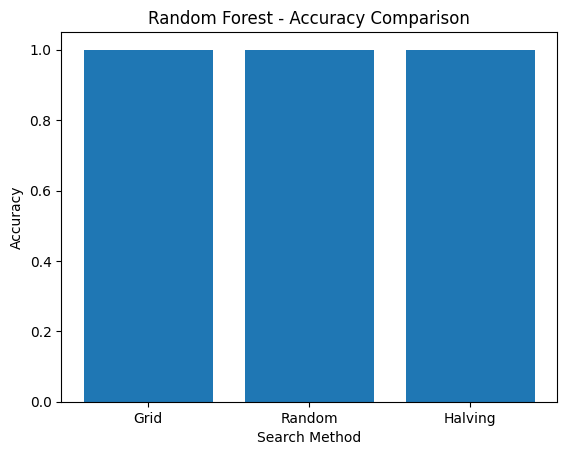

In [13]:
# Plot Accuracy Graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Random Forest - Accuracy Comparison")
plt.xlabel("Search Method")
plt.ylabel("Accuracy")
plt.show()

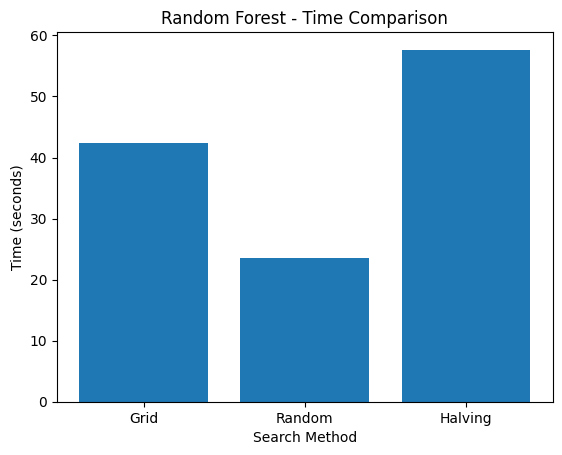

In [ ]:
# Plot Time Graph
plt.figure()
plt.bar(times.keys(), times.values())
plt.title("Random Forest - Time Comparison")
plt.xlabel("Search Method")
plt.ylabel("Time (seconds)")
plt.show()